# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Analytics_HW/yulu_rental.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [12]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [13]:
df.shape

(10886, 19)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  object 
 16  year         10886 non-null  int32  
 17  month        10886 non-null  int32  
 18  hour       

In [15]:
df.tail(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21
2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012-12-19,19,51,2,Wednesday,2012,12,22
2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,2012-12-19,19,51,2,Wednesday,2012,12,23


Набір даних містить **10886** рядків та **12** колонок.
Один рядок відповідає **одній годині** оренди велосипедів, тобто дані мають погодинний рівень деталізації.
Дані охоплюють період з **1 січня 2011 року до 19 грудня 2012 року**.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [16]:
daily_counts=df['count'].resample('D').sum()
daily_counts

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


In [17]:
daily_counts_clean=daily_counts.replace(0, None)

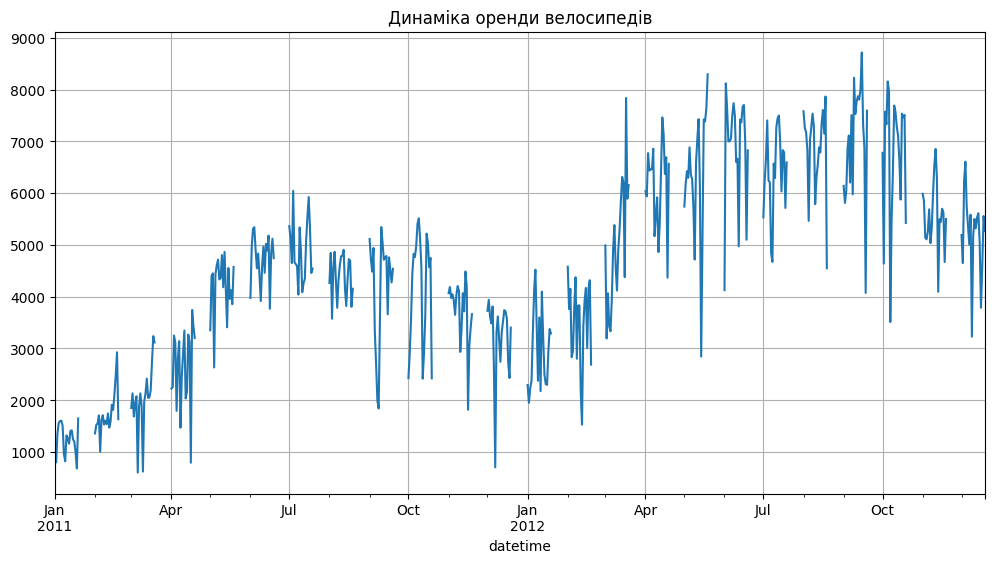

In [18]:
daily_counts_clean.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid=True
    )
plt.show()


In [19]:
daily_counts[daily_counts==0]

,count
datetime,
2011-01-20,0
2011-01-21,0
2011-01-22,0
2011-01-23,0
2011-01-24,0
...,...
2012-11-26,0
2012-11-27,0
2012-11-28,0


In [20]:
daily_counts.isna().sum()

np.int64(0)

1. Заломи на графіку виникають через відсутність даних у деякі дні. При агрегуванні даних методом resample() ці дні були заповнені нульовими значеннями, що створює різкі провали на графіку. Щоб прибрати заломи, можна замінити нульові значення на NaN або використати згладжування, наприклад, ковзне середнє.
2. На графіку видно загальну тенденцію до зростання кількості оренд велосипедів у 2012 році порівняно з 2011 роком. Це може свідчити про зростання популярності сервісу або збільшення кількості користувачів.
3. На графіку видно сезонні коливання: кількість оренд зростає у весняно-літній період та зменшується взимку. Це логічно, оскільки велосипеди частіше використовуються у теплу погоду.
4. На графіку помітні окремі різкі зниження значень. Це може бути пов’язано з погодними умовами, святковими днями або відсутністю даних у деякі дати. Також спостерігаються періоди з високими значеннями, що можуть пояснюватися сприятливою погодою або високою активністю користувачів у теплі місяці.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [21]:
season_avg=df.groupby('season')['count'].mean()
season_avg

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


In [22]:
season_avg.index=['Spring', 'Summer', 'Fall', 'Winter']

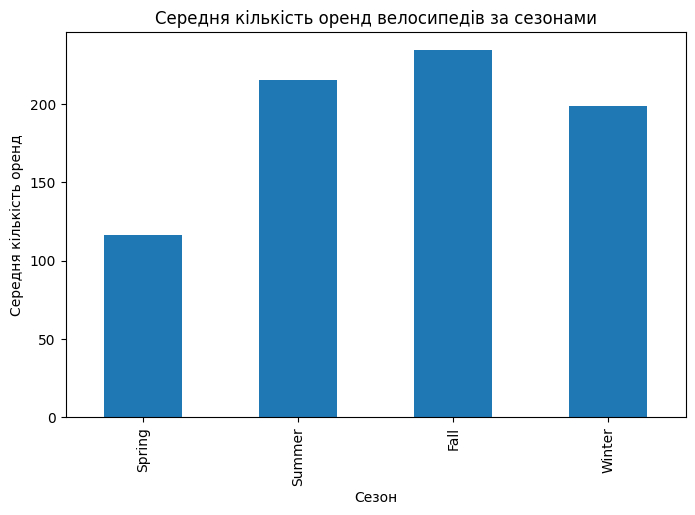

In [25]:
season_avg.plot(
    kind='bar',
    figsize=(8,5),
    title='Середня кількість оренд велосипедів за сезонами'
)

plt.xlabel('Сезон')
plt.ylabel('Середня кількість оренд')
plt.show()


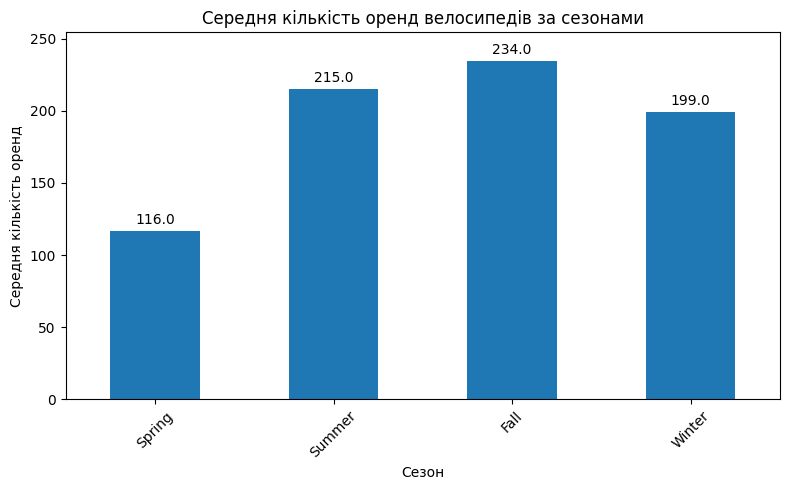

In [28]:
ax = season_avg.plot(kind='bar', figsize=(8,5))

for i, v in enumerate(season_avg):
    ax.text(i, v + 5, round(v,0), ha='center')

plt.title('Середня кількість оренд велосипедів за сезонами')
plt.xlabel('Сезон')
plt.ylabel('Середня кількість оренд')

plt.xticks(rotation=45)

plt.ylim(0, season_avg.max() + 20)
plt.tight_layout()

plt.show()

1. Найбільша кількість оренд спостерігається у теплі сезони (Summer, Fall).
2. Погодні умови в теплі сезони є більш сприятливими для використання велосипедів, адже взимку складніше в мороз персуватись велосипедами, ніж коли тепло.
3. Різниця між найпопулярнішим (Fall) і найменш популярним сезоном (Spring) становить приблизно 2 рази (точний показник = season_avg.max() / season_avg.min()=2.0148749597441986).

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [33]:
month_avg = df.groupby('month')['count'].mean()
month_avg

,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


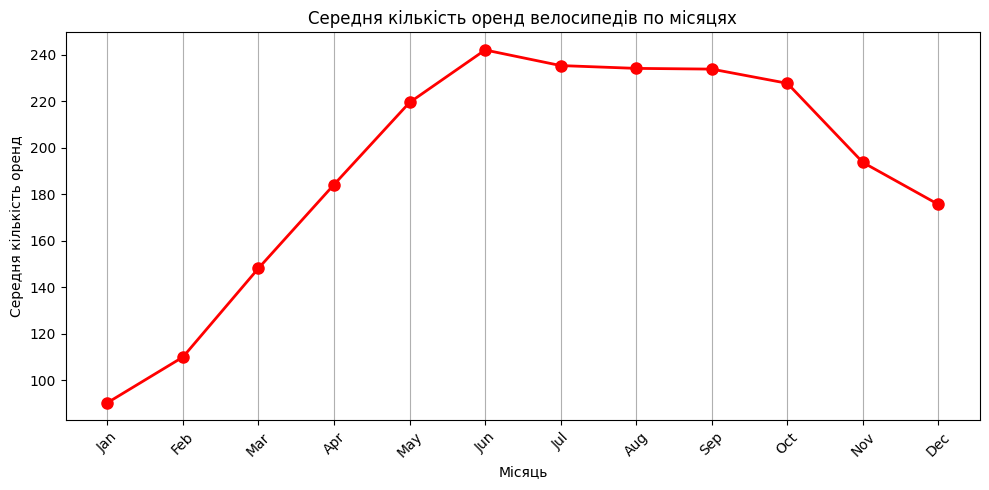

In [43]:
month_avg = df.groupby('month')['count'].mean()

month_avg.index = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']

month_avg.plot(
    figsize=(10,5),
    marker='o',
    markersize=8,
    linewidth=2,
    color='red',
    grid=True,
    title='Середня кількість оренд велосипедів по місяцях'
)

plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')

plt.xticks(rotation=45)
plt.tight_layout()
plt.xticks(range(12), month_avg.index)
plt.grid(axis='y')

plt.show()


1. Найбільший пік оренди велосипедів припадає на літо, та тримається не менш високо в місяці осені, на спад оренда велосипедів йде взимку - December, January etc.
2. Так, результати збігаються з попереднім аналізом сезонності, де найбільша кількість оренд також припадала на теплі сезони, а найменша - на зимовий період.
3. Основним фактором є клімат, оскільки погодні умови безпосередньо впливають на використання велосипедів.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

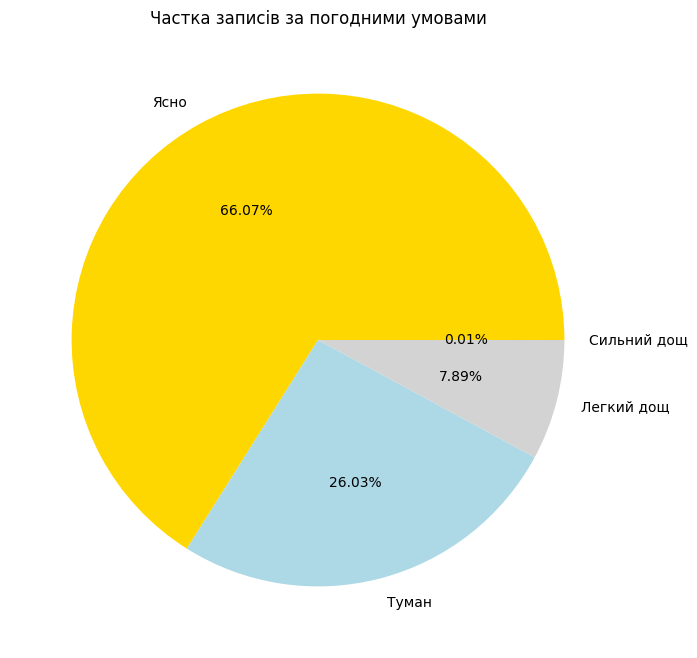

In [44]:
weather_counts = df['weather'].value_counts()
weather_counts

,count
weather,
1,7192
2,2834
3,859
4,1


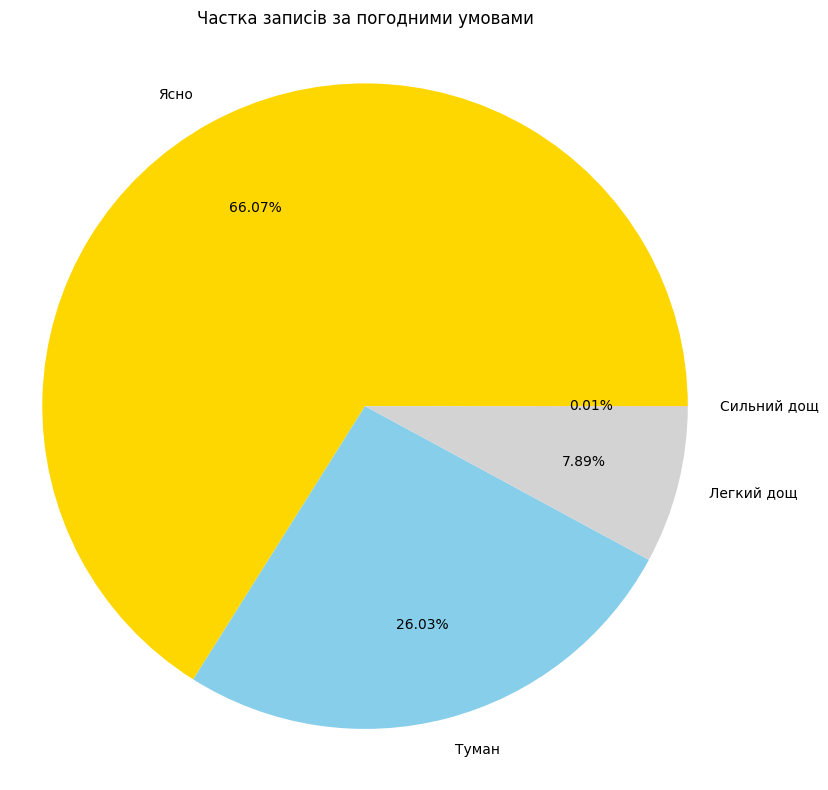

In [48]:
labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

colors = ['gold', 'skyblue', 'lightgrey', 'salmon']

weather_counts.plot(
    kind='pie',
    autopct='%1.2f%%',
    labels=labels,
    colors=colors,
    figsize=(8,8),
    pctdistance=0.7
)

plt.title('Частка записів за погодними умовами')
plt.ylabel('')

plt.tight_layout()
plt.axis('equal')
plt.show()

1. У датасеті переважає ясна погода (Ясно=66,07%), що логічно, оскільки більшість днів протягом року мають сприятливі погодні умови.
2. Дні із сильним дощем присутні, але їх частка є дуже малою (0,01%). Це означає, що несприятливі погодні умови трапляються значно рідше.
3. Аналіз показує, що більшість днів мають ясну погоду. Частка днів із сильним дощем є дуже незначною. Погодні умови суттєво впливають на використання велосипедів: у сприятливу погоду попит зростає, а у несприятливу - зменшується.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

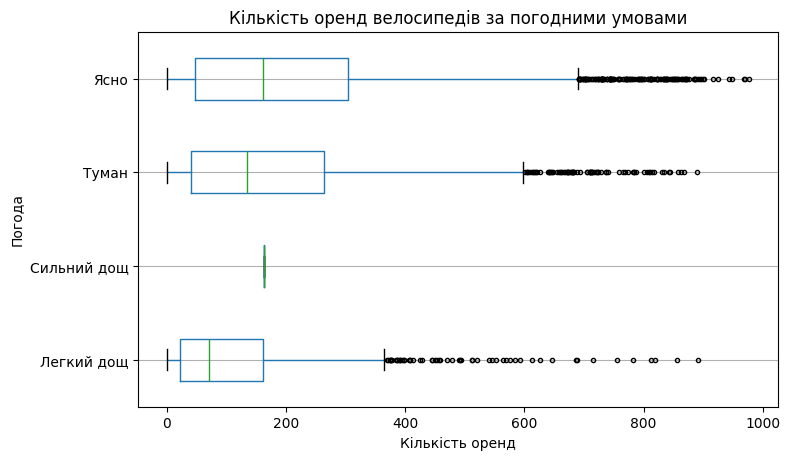

In [58]:
weather_names = {
    1:'Ясно',
    2:'Туман',
    3:'Легкий дощ',
    4:'Сильний дощ'
}

df['weather_name'] = df['weather'].map(weather_names)

df.boxplot(
    column='count',
    by='weather_name',
    vert=False,
    figsize=(8,5),
    flierprops=dict(markersize=3)
)

plt.title('Кількість оренд велосипедів за погодними умовами')
plt.xlabel('Кількість оренд')
plt.ylabel('Погода')

plt.suptitle('')
plt.grid(axis='x')

plt.show()

1. Найбільший розкид кількості оренд спостерігається при Ясній погоді, оскільки саме в цей період відбувається найбільша кількість оренд.
2. У даних присутні викиди, особливо при Ясній погоді. Це можуть бути дні з дуже високим попитом або особливо сприятливими умовами.
3. Найвище медіанне значення оренд спостерігається при Ясній погоді, що підтверджує залежність попиту від погодних умов.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

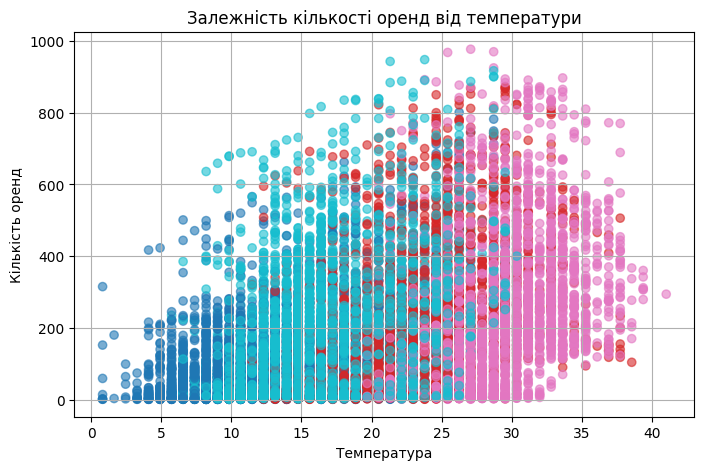

In [73]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['temp'],
    df['count'],
    alpha=0.6,
    c=df['season'],
    cmap='tab10'
)

plt.xlabel('Температура')
plt.ylabel('Кількість оренд')
plt.title('Залежність кількості оренд від температури')
plt.grid(True)

plt.show()

In [71]:
df[['temp','count']].corr()

,temp,count
temp,1.000000,0.394454
count,0.394454,1.000000


Кореляція між температурою та кількістю оренд є позитивною, що підтверджує наявність залежності.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?